In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Medicalpremium.csv')

In [4]:
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [5]:
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


In [6]:
df.isnull().sum()

Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64

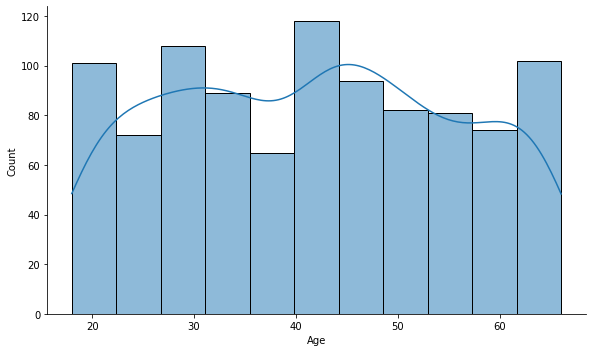

In [7]:
sns.displot(x='Age',data=df,aspect=10/6,kde=True)

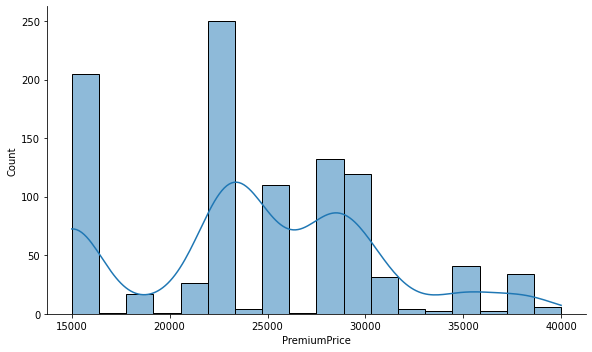

In [8]:
sns.displot(x='PremiumPrice',data=df,aspect=10/6,kde=True)

In [9]:
pr_lab=['Low','Basic','Average','High','SuperHigh']
df['PremiumLabel']=pr_bins=pd.cut(df['PremiumPrice'],bins=5,labels=pr_lab,precision=0)

In [10]:
df.columns

Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice',
       'PremiumLabel'],
      dtype='object')

In [11]:
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,PremiumLabel
0,45,0,0,0,0,155,57,0,0,0,25000,Basic
1,60,1,0,0,0,180,73,0,0,0,29000,Average
2,36,1,1,0,0,158,59,0,0,1,23000,Basic
3,52,1,1,0,1,183,93,0,0,2,28000,Average
4,38,0,0,0,1,166,88,0,0,1,23000,Basic


<AxesSubplot:xlabel='PremiumLabel', ylabel='Age'>

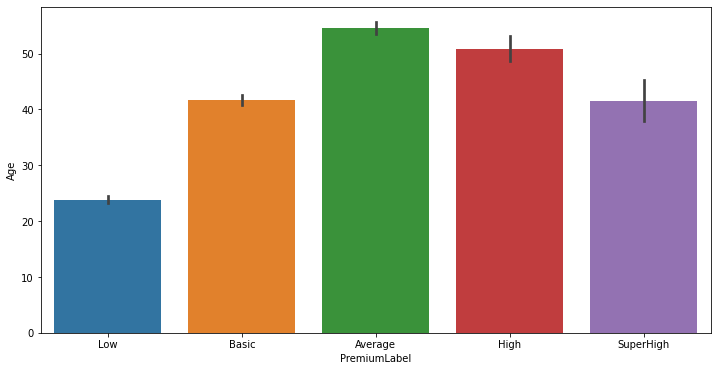

In [12]:
fig,ax=plt.subplots(figsize=(12,6))
sns.barplot(y='Age',x='PremiumLabel',data=df,ax=ax)

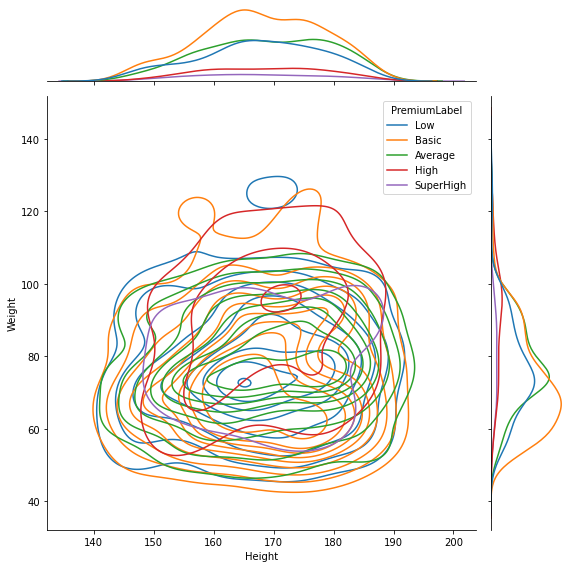

In [13]:
sns.jointplot(x='Height',y='Weight',data=df,hue='PremiumLabel',height=8,kind='kde')


In [14]:
age_lab=['Teen','Young','Middle','Old','SuperOld']
df['AgeLabel']=pd.cut(df['Age'],bins=5,labels=age_lab,precision=0)

In [15]:
df.columns

Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice',
       'PremiumLabel', 'AgeLabel'],
      dtype='object')

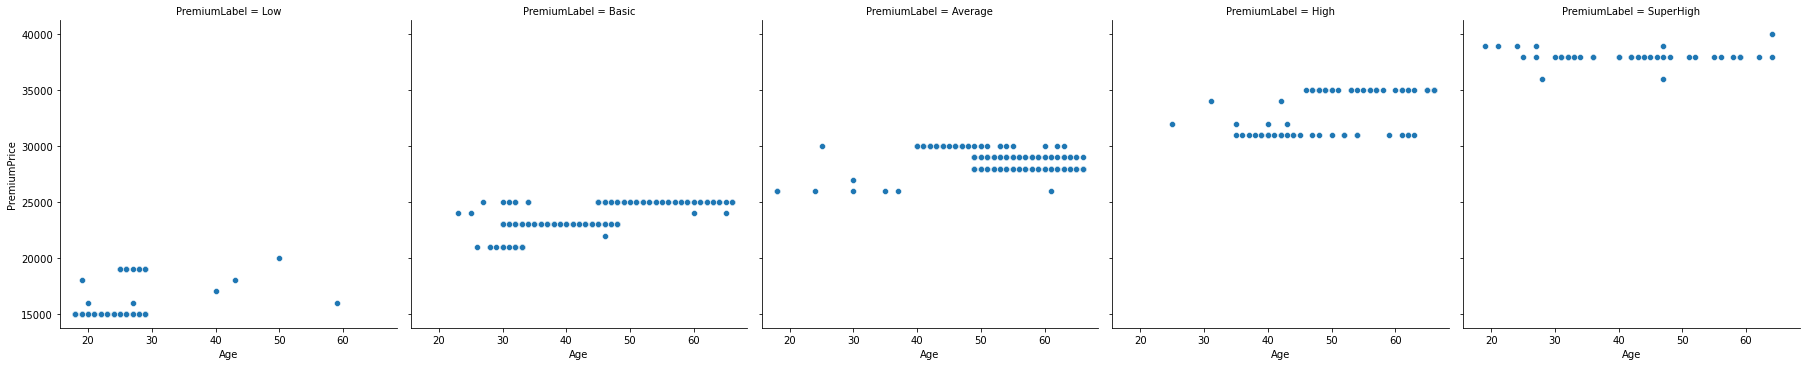

In [16]:
sns.relplot(x='Age',y='PremiumPrice',data=df,col='PremiumLabel',aspect=10/10)

<AxesSubplot:xlabel='PremiumLabel', ylabel='Age'>

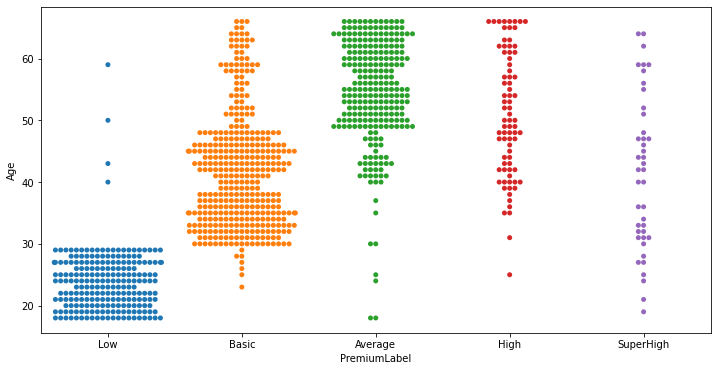

In [17]:
fig,ax=plt.subplots(figsize=(12,6))
sns.swarmplot(x='PremiumLabel',y='Age',data=df,ax=ax)

# Converting new categorical columns to numeric ones¶

In [18]:
df=pd.get_dummies(data=df,columns=['AgeLabel','PremiumLabel'])

In [19]:
df.columns

Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice',
       'AgeLabel_Teen', 'AgeLabel_Young', 'AgeLabel_Middle', 'AgeLabel_Old',
       'AgeLabel_SuperOld', 'PremiumLabel_Low', 'PremiumLabel_Basic',
       'PremiumLabel_Average', 'PremiumLabel_High', 'PremiumLabel_SuperHigh'],
      dtype='object')

In [20]:
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,...,AgeLabel_Teen,AgeLabel_Young,AgeLabel_Middle,AgeLabel_Old,AgeLabel_SuperOld,PremiumLabel_Low,PremiumLabel_Basic,PremiumLabel_Average,PremiumLabel_High,PremiumLabel_SuperHigh
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,...,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,...,0.202840,0.209939,0.196755,0.199797,0.190669,0.227181,0.388438,0.262677,0.079108,0.042596
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,...,0.402318,0.407472,0.397747,0.400051,0.393028,0.419223,0.487642,0.440312,0.270043,0.202048
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,...,AgeLabel_Teen,AgeLabel_Young,AgeLabel_Middle,AgeLabel_Old,AgeLabel_SuperOld,PremiumLabel_Low,PremiumLabel_Basic,PremiumLabel_Average,PremiumLabel_High,PremiumLabel_SuperHigh
0,45,0,0,0,0,155,57,0,0,0,...,0,0,1,0,0,0,1,0,0,0
1,60,1,0,0,0,180,73,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2,36,1,1,0,0,158,59,0,0,1,...,0,1,0,0,0,0,1,0,0,0
3,52,1,1,0,1,183,93,0,0,2,...,0,0,0,1,0,0,0,1,0,0
4,38,0,0,0,1,166,88,0,0,1,...,0,0,1,0,0,0,1,0,0,0


In [22]:
df.shape

(986, 21)

In [23]:
x=df.drop('PremiumPrice',axis=1)
y=df['PremiumPrice']

In [24]:
x.columns

Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'AgeLabel_Teen',
       'AgeLabel_Young', 'AgeLabel_Middle', 'AgeLabel_Old',
       'AgeLabel_SuperOld', 'PremiumLabel_Low', 'PremiumLabel_Basic',
       'PremiumLabel_Average', 'PremiumLabel_High', 'PremiumLabel_SuperHigh'],
      dtype='object')

In [25]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xsc=sc.fit_transform(x)

In [26]:
xsc=pd.DataFrame(xsc,columns=x.columns)

In [27]:
from sklearn.feature_selection import mutual_info_regression
mi_scores = mutual_info_regression(xsc,y)
mi_scores = pd.Series(mi_scores, name="MI Scores",index=xsc.columns)
mi_scores = mi_scores.sort_values(ascending=False)
(mi_scores*100).head(15).index

Index(['Age', 'PremiumLabel_Basic', 'PremiumLabel_Average', 'PremiumLabel_Low',
       'NumberOfMajorSurgeries', 'AgeLabel_Teen', 'PremiumLabel_High',
       'AgeLabel_SuperOld', 'Weight', 'AgeLabel_Middle', 'AgeLabel_Young',
       'PremiumLabel_SuperHigh', 'AnyChronicDiseases', 'AgeLabel_Old',
       'HistoryOfCancerInFamily'],
      dtype='object')

In [28]:
fea=['Age', 'PremiumLabel_Basic', 'PremiumLabel_Average', 'PremiumLabel_Low',
       'NumberOfMajorSurgeries', 'AgeLabel_Teen', 'PremiumLabel_High',
       'Weight', 'AgeLabel_SuperOld', 'AgeLabel_Middle',
       'PremiumLabel_SuperHigh', 'AgeLabel_Young', 'AgeLabel_Old',
       'AnyChronicDiseases', 'AnyTransplants']
xsc=xsc[fea]

In [29]:
y.shape

(986,)

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
xtr,xte,ytr,yte=train_test_split(xsc,y,random_state=33,test_size=0.3)

# BUILDING MODEL

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [33]:
reg=RandomForestRegressor(n_jobs=-1,verbose=2)
param_grid={'n_estimators':[60,50,55],'criterion':['mse','mae'],'max_depth':[7],'min_samples_split':[3],'max_features':['auto']}
gs=GridSearchCV(reg,param_grid=param_grid,cv=3,n_jobs=-1,verbose=1)

In [34]:
gs.fit(xtr,ytr)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.


building tree 1 of 60building tree 2 of 60building tree 3 of 60
building tree 4 of 60


building tree 5 of 60
building tree 6 of 60
building tree 7 of 60
building tree 8 of 60building tree 9 of 60building tree 10 of 60


building tree 11 of 60building tree 12 of 60building tree 13 of 60


building tree 14 of 60
building tree 15 of 60
building tree 16 of 60building tree 17 of 60

building tree 18 of 60
building tree 19 of 60
building tree 20 of 60
building tree 21 of 60building tree 22 of 60

building tree 23 of 60building tree 24 of 60

building tree 25 of 60building tree 26 of 60

building tree 27 of 60
building tree 28 of 60
building tree 29 of 60
building tree 30 of 60
building tree 31 of 60building tree 32 of 60

building tree 33 of 60
building tree 34 of 60building tree 35 of 60

building tree 36 of 60
building tree 37 of 60


[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    0.5s


building tree 38 of 60building tree 39 of 60

building tree 40 of 60
building tree 41 of 60
building tree 42 of 60
building tree 43 of 60building tree 44 of 60

building tree 45 of 60
building tree 46 of 60
building tree 47 of 60
building tree 48 of 60
building tree 49 of 60building tree 50 of 60

building tree 51 of 60
building tree 52 of 60
building tree 53 of 60
building tree 54 of 60
building tree 55 of 60
building tree 56 of 60
building tree 57 of 60
building tree 58 of 60building tree 59 of 60

building tree 60 of 60


[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.8s finished


GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, verbose=2),
             n_jobs=-1,
             param_grid={'criterion': ['mse', 'mae'], 'max_depth': [7],
                         'max_features': ['auto'], 'min_samples_split': [3],
                         'n_estimators': [60, 50, 55]},
             verbose=1)

In [35]:
gs.best_params_

{'criterion': 'mse',
 'max_depth': 7,
 'max_features': 'auto',
 'min_samples_split': 3,
 'n_estimators': 60}

In [36]:
gs.best_score_

0.9951966156455597

In [37]:
predicted_y=gs.predict(xte)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done  60 out of  60 | elapsed:    0.0s finished
